In [2]:
import numpy as np
from PIL import Image
import taichi as ti
from scipy.ndimage import zoom
import matplotlib.pyplot as plt
from utils import run_optimization, resample_polyline, get_area

ti.init(arch=ti.gpu)

[Taichi] version 1.7.3, llvm 15.0.1, commit 5ec301be, win, python 3.12.3
[Taichi] Starting on arch=cuda


(-2.9625, 1.7125, -3.9625, 0.7125)

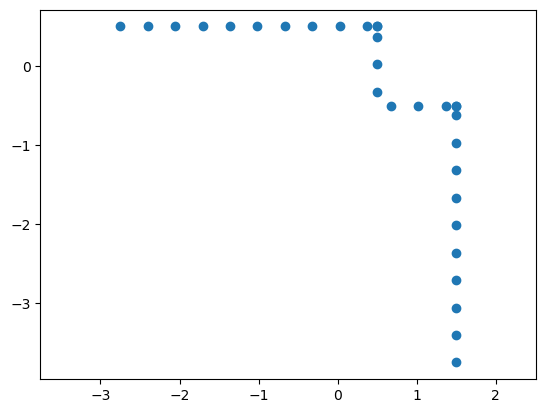

In [31]:
def init_trajectory(sofa_w, sofa_h, control_point_num):  # 生成初始轨迹
    middle_rotation = -0.25 * np.pi
    xs, ys, rotations = resample_polyline([
        [-sofa_w / 2, 0.5, 0],
        [0.5, 0.5, 0],
        [0.5, 0.5, middle_rotation],
        [0.5, -0.5, middle_rotation],
        [1.5, -0.5, middle_rotation],
        [1.5, -0.5, middle_rotation * 2],
        [1.5, -1 - sofa_w / 2, middle_rotation * 2]
    ], control_point_num).T
    return xs, ys, rotations

sofa_w = 5.5   # 求解域的尺寸
sofa_h = 1.0   # 求解域的尺寸

xs, ys, rotations = init_trajectory(  # 初始轨迹
    sofa_w=sofa_w,
    sofa_h=sofa_h,
    control_point_num=30,  # 轨迹的控制点数量
)

plt.scatter(xs, ys)
plt.axis('equal')

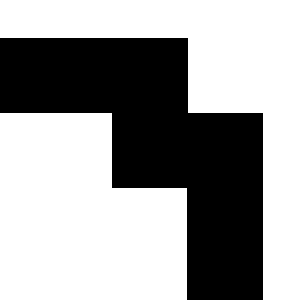

In [32]:
# 可视化墙（白色区域为墙）

from utils import test_forbidden_function

@ti.func
def is_forbidden(x1, y1, x2, y2):  # 指定哪里是墙
    return x2 > 2 or y2 > 1 or (x2 < 0 and y2 < 0) or (x2 < 1 and y2 < -1) or (x2  > 1 and y2 > 0)

image = test_forbidden_function(
    is_forbidden,
    -1.5, 2.5, -2.5, 1.5, 300,
    # wall_normal=[0, 0.05]
)
Image.fromarray(np.array(image.T[::-1] * 255, dtype=np.uint8))

In [40]:
xs, ys, rotations = np.load('../trajectory/3拐角/sofa_600.npy')

Initial survivors: 2.687932014465332
iter 500 / 20000, maximal_area=2.694841146469116
iter 1000 / 20000, maximal_area=2.6959168910980225
iter 1500 / 20000, maximal_area=2.69731068611145
iter 2000 / 20000, maximal_area=2.698007583618164
iter 2500 / 20000, maximal_area=2.699772834777832
iter 3000 / 20000, maximal_area=2.7011213302612305
iter 3500 / 20000, maximal_area=2.7022955417633057
iter 4000 / 20000, maximal_area=2.7022955417633057
iter 4500 / 20000, maximal_area=2.7025532722473145
iter 5000 / 20000, maximal_area=2.7029924392700195
iter 5500 / 20000, maximal_area=2.70383358001709
iter 6000 / 20000, maximal_area=2.704272747039795
iter 6500 / 20000, maximal_area=2.704272747039795
iter 7000 / 20000, maximal_area=2.7046213150024414
iter 7500 / 20000, maximal_area=2.7051970958709717
iter 8000 / 20000, maximal_area=2.705212116241455
iter 8500 / 20000, maximal_area=2.7053561210632324
iter 9000 / 20000, maximal_area=2.7053864002227783
iter 9500 / 20000, maximal_area=2.7053864002227783
iter 

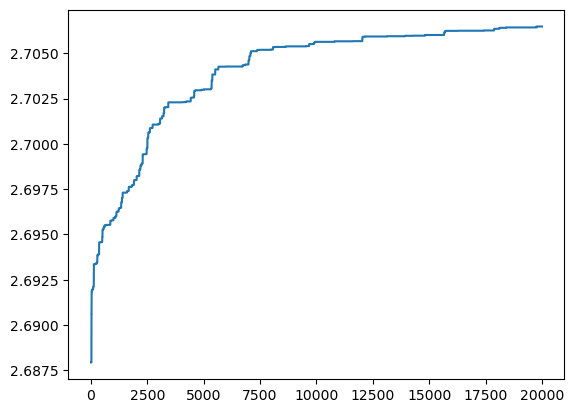

In [41]:
best_score, xs, ys, rotations, sofa, maximal_area_record = run_optimization(
    is_forbidden,
    # xs,
    # ys,
    # rotations,
    initial_xs=zoom(xs, zoom=2, order=1),
    initial_ys=zoom(ys, zoom=2, order=1),
    initial_rotations=zoom(rotations, zoom=2, order=1),
    sofa_w=sofa_w,
    sofa_h=sofa_h,
    mutation_sigma_pos = 0.02,  # 变异率
    mutation_sigma_rotation = 0.004,  # 变异率
    iterations = 20000,  # 200000
    trajectory_upsampling=101,  # 41 101
    resolution=2000,  # 1024 2000
    print_every=500,  # 1000
    save_image_every=83,
    save_image_path='../images/3拐角/sofa_',
    save_image_start_id=600,
    save_trajectory_path='../trajectory/3拐角/sofa_'
)
print(f"Estimated maximal sofa area (by sampling): {best_score:.5f}")
# save mask image as PNG if pillow is available

img = (sofa * 255).astype(np.uint8)
im = Image.fromarray(img.T[::-1])
im.save('../sofa_survivors.png')
plt.plot(maximal_area_record)